# Brazillian E-commerce Investigation
Import neccessary libraries

# Objectives
Analyse historical Brazilian Olist Online Store Data .
Identify trends, patterns, and key insights from the dataset
Develop predictive models to forecast future rankings
Prepare a cleaned dataset for visualisations in Tableau ....

# Inputs
'olist_customers_dataset.csv' 
'olist_geolocation_dataset.csv'
'olist_order_items_dataset.csv'
'olist_order_payments_dataset.csv'
'olist_order_reviews_dataset.csv'
'olist_products_dataset.csv'
'olist_sellers_dataset.csv'
'product_category_name_translation.csv'

# Outputs
1.Initial merged dataset: 'order_items_merged.csv'


# Additional Comments
Ensure data integrity by handling missing values and duplicates
Ethical considerations include recognising data biases and cultural influences in ranking trends

To analyse the Brazilian Olist online store  dataset effectively, the following steps are taken:

1. Data Understanding and Preparation
Each CSV files dataset is checked for null values and duplicates, ensuring data integrity
Attributes are standardised to maintain consistency

### Set a new directory

In [368]:
import os
current_dir = os.getcwd()
current_dir

'/Users/anita/Documents/vscode-projects/capstone-analysis/jupyter_notebooks'

### Import Libraries

 The Olist Brazilian online store dataset will be loaded into this notebook, to gain insight into the data and conduct data cleaning.

In [434]:
#Import necessary Python libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
pd.set_option('display.max_columns', None)
from scipy.stats import chi2_contingency, ttest_ind


### Extract- Read and load all the CSV files

In [370]:
# Load dataset and convert to DataFrame
csv_files = {
'customers': 'olist_customers_dataset.csv',
'orders': 'olist_orders_dataset.csv',
'order_items': 'olist_order_items_dataset.csv',
'order_payments': 'olist_order_payments_dataset.csv',
'order_reviews': 'olist_order_reviews_dataset.csv',
'products': 'olist_products_dataset.csv',
'sellers': 'olist_sellers_dataset.csv',
'geolocation': 'olist_geolocation_dataset.csv',
'category_translation': 'product_category_name_translation.csv'
}

dataframes = {}
for name, filename in csv_files.items():
    dataframes[name] = pd.read_csv(f"../data/brazilian_csv/{filename}")
    print(f"Loaded {name}: {dataframes[name].shape}")


df_customers = dataframes['customers']
df_orders = dataframes['orders']
df_order_items = dataframes['order_items']
df_order_payments = dataframes['order_payments']
df_order_reviews = dataframes['order_reviews']
df_products = dataframes['products']
df_sellers = dataframes['sellers']
df_geolocation = dataframes['geolocation']
df_category_translation = dataframes['category_translation']

Loaded customers: (99441, 5)
Loaded orders: (99441, 8)
Loaded order_items: (112650, 7)
Loaded order_payments: (103886, 5)
Loaded order_reviews: (99224, 7)
Loaded products: (32951, 9)
Loaded sellers: (3095, 4)
Loaded geolocation: (1000163, 5)
Loaded category_translation: (71, 2)


Investigate the size of each dataset

customers: (99441, 5)
orders: (99441, 8)
order_items: (112650, 7)
order_payments: (103886, 5)
order_reviews: (99224, 7)
products: (32951, 9)
sellers: (3095, 4)
geolocation: (1000163, 5)
category_translation: (71, 2)

### Inspect each set of data

In [371]:
df_customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


The data has no erros 

In [ ]:
#Preview thefirst five rows for inspection
df_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


There are 4 objects in the customer data. There is 1 integer. There is no null value.

In [ ]:
#Preview the first five rows for inspection
df_geolocation.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


The data has no errors.

In [ ]:
#Provide a summary of the geolocation dataset
df_geolocation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


There is one integer in geolocation data.  There are two floats and two objects. There is no null value.

In [ ]:
#Preview the first five rows for inspection 
df_order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


The data is cleaned with no errors.

In [ ]:
#Display the column data types and check for null or missing values
df_order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


There are four objects in order item data. There are two floats and one integer. There is no null value.

In [377]:
df_order_items.describe()

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


The mean / average price of the order items is 121 BRL. 
The minimum price is 0.85 BRL
The maximum price is 6735 BRL

The mean / average freight value for the order items is 20 BRL
The minimum fright value is 0 BRL which indicates that there is free option of shipping available.
The maximum freight value is 410 BRL



In [378]:
df_order_payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [379]:
df_order_payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


There are two objects in order payments data. There are one float and two integers. There is no null value.

In [380]:
df_order_payments.describe()

,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000



The mean / average price of the order payment sequential is 1. 
The minimum payment sequential is 1
The maximum payment sequential is 29
Most orders are paid in single attempt.


The mean / average payment instalments for the order items is 3
The minimum payment values is 0  which indicates that there is free or failed paymemnts or data issues
The maximum payment values is 13554 BRL

The minimum value of 0 for both payment installments and payment values may include is free products, refunds or missing data


In [381]:
df_order_reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


The code

In [382]:
df_order_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


There are 6 objects and 1 integer. Column 3 and 4 contain null values.

In [383]:
df_order_reviews.describe()

,review_score
count,99224.000000
mean,4.086421
std,1.347579
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


The mean score of order reviews is 4. 
The minimum score of order reviews is 1.
The maximum score of order reviews is 5.

In [384]:
df_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [385]:
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


Column 4, 5 and 6 contain null values and all coloumns are object data type.

In [386]:
df_products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [387]:
df_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


All columns except column 1 which is product_id contain null values.
There are 7 floats and 2 objects.

In [388]:
df_sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [389]:
df_sellers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


There is no null values in sellers data. There are 3 objects and 1 integer.

In [390]:
df_category_translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [391]:
df_category_translation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


There is no null value in category translation. They are all objects.

---

### Data Cleaning 

In [392]:
# Check for duplicates in each dataset
# List of all your dataframes with their names
datasets = {
    "df_customers": df_customers,
    "df_geolocation": df_geolocation,
    "df_order_items": df_order_items,
    "df_order_payments": df_order_payments,
    "df_order_reviews": df_order_reviews,
    "df_orders": df_orders,
    "df_products": df_products,
    "df_sellers": df_sellers,
    "df_category_translation": df_category_translation
}


for name, df in datasets.items():
    print(f"{name} - Shape: {df.shape}, Duplicates: {df.duplicated().sum()}")


df_customers - Shape: (99441, 5), Duplicates: 0
df_geolocation - Shape: (1000163, 5), Duplicates: 261831
df_order_items - Shape: (112650, 7), Duplicates: 0
df_order_payments - Shape: (103886, 5), Duplicates: 0
df_order_reviews - Shape: (99224, 7), Duplicates: 0
df_orders - Shape: (99441, 8), Duplicates: 0
df_products - Shape: (32951, 9), Duplicates: 0
df_sellers - Shape: (3095, 4), Duplicates: 0
df_category_translation - Shape: (71, 2), Duplicates: 0


In [393]:
# Check missing values
for name, df in datasets.items():
    print(f"\n{name} Missing Values:")
    print(df.isnull().sum())


df_customers Missing Values:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

df_geolocation Missing Values:
geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64

df_order_items Missing Values:
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

df_order_payments Missing Values:
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

df_order_reviews Missing Values:
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247


In [394]:
# Don't drop these - missing comments are normal customer behavior!
# Just fill with "No Comment" if needed for analysis
df_order_reviews['review_comment_title'].fillna('No Title', inplace=True)
df_order_reviews['review_comment_message'].fillna('No Message', inplace=True)

In [395]:
# Drop rows with any missing values
df_orders = df_orders.dropna()


In [396]:
# 1. Category name - use 'Unknown' or most frequent category
df_products['product_category_name'].fillna('outros', inplace=True) # 'others' in Portuguese

# 2. Numeric features - use median (robust to outliers)
numeric_cols = ['product_name_lenght', 'product_description_lenght', 'product_photos_qty',
'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

for col in numeric_cols:
    median_value = df_products[col].median()
    df_products[col].fillna(median_value, inplace=True)
    print(f"Filled {col} with median: {median_value}")

Filled product_name_lenght with median: 51.0
Filled product_description_lenght with median: 595.0
Filled product_photos_qty with median: 1.0
Filled product_weight_g with median: 700.0
Filled product_length_cm with median: 25.0
Filled product_height_cm with median: 13.0
Filled product_width_cm with median: 20.0


--- 

### Data Preprocessing

In [397]:
datetime_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

# Convert each column to datetime
for col in datetime_columns:
    df_orders[col] = pd.to_datetime(df_orders[col], errors='coerce')  # errors='coerce' will set invalid parsing as NaT

# Optional: check data types to confirm
print(df_orders[datetime_columns].dtypes)

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


/var/folders/hf/46nj1q753jx0d3gy7yg3ns6c0000gn/T/ipykernel_15073/1992088276.py:11: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/hf/46nj1q753jx0d3gy7yg3ns6c0000gn/T/ipykernel_15073/1992088276.py:11: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/hf/46nj1q753jx0d3gy7yg3ns6c0000gn/T/ipykernel_15073/1992088276.py:11: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in th

In [ ]:
Display the column data types and check for null or missing values
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96461 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96461 non-null  object        
 1   customer_id                    96461 non-null  object        
 2   order_status                   96461 non-null  object        
 3   order_purchase_timestamp       96461 non-null  datetime64[ns]
 4   order_approved_at              96461 non-null  datetime64[ns]
 5   order_delivered_carrier_date   96461 non-null  datetime64[ns]
 6   order_delivered_customer_date  96461 non-null  datetime64[ns]
 7   order_estimated_delivery_date  96461 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.6+ MB


In [399]:
print("Creating Master Dataset...")

# Merge orders with customers
master_df = df_orders.merge(df_customers, on='customer_id', how='left')

# Merge with order items
master_df = master_df.merge(df_order_items, on='order_id', how='left')

# Merge with products
master_df = master_df.merge(df_products, on='product_id', how='left')

# Merge with English product category names
master_df = master_df.merge(df_category_translation,
                           on='product_category_name', how='left')

# Merge with order payments
order_payments_agg = df_order_payments.groupby('order_id').agg({
    'payment_sequential': 'max',
    'payment_type': lambda x: ', '.join(x.unique()),
    'payment_installments': 'mean',
    'payment_value': 'sum'
}).reset_index()

master_df = master_df.merge(order_payments_agg, on='order_id', how='left')

# Merge with seller and geolocation data
master_df = master_df.merge(df_sellers, on='seller_id', how='left', suffixes=('', '_seller'))

# Add customer geolocation
customer_geo = df_geolocation.groupby('geolocation_zip_code_prefix').agg({
    'geolocation_lat': 'mean',
    'geolocation_lng': 'mean',
    'geolocation_city': 'first',
    'geolocation_state': 'first'
}).reset_index()

master_df = master_df.merge(customer_geo,
                           left_on='customer_zip_code_prefix',
                           right_on='geolocation_zip_code_prefix',
                           how='left', suffixes=('', '_customer'))

print(f"Master dataset shape: {master_df.shape}")
print(f"Columns: {master_df.columns.tolist()}")

Creating Master Dataset...
Master dataset shape: (110180, 39)
Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_category_name_english', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value', 'seller_zip_code_prefix', 'seller_city', 'seller_state', 'geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geolocation_state']


In [400]:
master_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,payment_sequential,payment_type,payment_installments,payment_value,seller_zip_code_prefix,seller_city,seller_state,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares,3.0,"credit_card, voucher",1.0,38.71,9350,maua,SP,3149.0,-23.576983,-46.587161,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery,1.0,boleto,1.0,141.46,31570,belo horizonte,SP,47813.0,-12.177924,-44.660711,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto,1.0,credit_card,3.0,179.12,14840,guariba,SP,75265.0,-16.745150,-48.514783,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,pet_shop,1.0,credit_card,1.0,72.20,31842,belo horizonte,MG,59296.0,-5.774190,-35.271143,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,stationery,1.0,credit_card,1.0,28.62,8752,mogi das cruzes,SP,9195.0,-23.676370,-46.514627,santo andre,SP


In [ ]:
# Display the column data types and check for null or missing values
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110180 entries, 0 to 110179
Data columns (total 39 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       110180 non-null  object        
 1   customer_id                    110180 non-null  object        
 2   order_status                   110180 non-null  object        
 3   order_purchase_timestamp       110180 non-null  datetime64[ns]
 4   order_approved_at              110180 non-null  datetime64[ns]
 5   order_delivered_carrier_date   110180 non-null  datetime64[ns]
 6   order_delivered_customer_date  110180 non-null  datetime64[ns]
 7   order_estimated_delivery_date  110180 non-null  datetime64[ns]
 8   customer_unique_id             110180 non-null  object        
 9   customer_zip_code_prefix       110180 non-null  int64         
 10  customer_city                  110180 non-null  object        
 11  

In [402]:
datetime_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'shipping_limit_date',

]

# Convert each column to datetime
for col in datetime_columns:
    master_df[col] = pd.to_datetime(master_df[col], errors='coerce')  # errors='coerce' will set invalid parsing as NaT

# Optional: check data types to confirm
print(master_df[datetime_columns].dtypes)

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
shipping_limit_date              datetime64[ns]
dtype: object


In [ ]:
#Display the column data types and check for null or missing values
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110180 entries, 0 to 110179
Data columns (total 39 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       110180 non-null  object        
 1   customer_id                    110180 non-null  object        
 2   order_status                   110180 non-null  object        
 3   order_purchase_timestamp       110180 non-null  datetime64[ns]
 4   order_approved_at              110180 non-null  datetime64[ns]
 5   order_delivered_carrier_date   110180 non-null  datetime64[ns]
 6   order_delivered_customer_date  110180 non-null  datetime64[ns]
 7   order_estimated_delivery_date  110180 non-null  datetime64[ns]
 8   customer_unique_id             110180 non-null  object        
 9   customer_zip_code_prefix       110180 non-null  int64         
 10  customer_city                  110180 non-null  object        
 11  

---

### Data Cleaning of Master Data

In [404]:
master_df.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                   0
order_delivered_carrier_date        0
order_delivered_customer_date       0
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
product_category_name               0
product_name_lenght                 0
product_description_lenght          0
product_photos_qty                  0
product_weight_g                    0
product_length_cm                   0
product_height_cm                   0
product_width_cm                    0
product_cate

In [405]:
master_df = master_df.dropna()


In [406]:
master_df.isnull().sum()

order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
customer_unique_id               0
customer_zip_code_prefix         0
customer_city                    0
customer_state                   0
order_item_id                    0
product_id                       0
seller_id                        0
shipping_limit_date              0
price                            0
freight_value                    0
product_category_name            0
product_name_lenght              0
product_description_lenght       0
product_photos_qty               0
product_weight_g                 0
product_length_cm                0
product_height_cm                0
product_width_cm                 0
product_category_name_english    0
payment_sequential               0
payment_type        

In [407]:
# Mixed Approach Downsampling: Time + Category + Customer Focused

# Set random seed for reproducibility
np.random.seed(42)

print(f"Original master_df shape: {master_df.shape}")
print(f"Original date range: {master_df['order_purchase_timestamp'].min()} to {master_df['order_purchase_timestamp'].max()}")
print(f"Original unique customers: {master_df['customer_unique_id'].nunique()}")
print(f"Original unique categories: {master_df['product_category_name_english'].nunique()}")


# Step 1: Create time periods for stratification
master_df['year_month'] = master_df['order_purchase_timestamp'].dt.to_period('M')

# Step 2: Time-based sampling (60% of 8000 = 4800 rows)
time_sample_size = 4800
period_counts = master_df['year_month'].value_counts().sort_index()

# Calculate proportional sample sizes per time period
period_samples = (period_counts / period_counts.sum() * time_sample_size).round().astype(int)
period_samples = period_samples.clip(upper=period_counts)

# Adjust to ensure exactly 4800 rows
current_total = period_samples.sum()
diff = time_sample_size - current_total

if diff > 0:
    # Add to largest periods
    largest_periods = period_samples.nlargest(diff).index
    for period in largest_periods:
        period_samples[period] += 1
elif diff < 0:
    # Subtract from largest periods
    largest_periods = period_samples.nlargest(abs(diff)).index
    for period in largest_periods:
        period_samples[period] -= 1

print(f"\nTime-based sampling: {period_samples.sum()} rows")

# Perform time-stratified sampling
time_sampled_dfs = []
for period, sample_size in period_samples.items():
    if sample_size > 0:
        period_data = master_df[master_df['year_month'] == period]
        if len(period_data) >= sample_size:
            time_sampled_dfs.append(period_data.sample(n=sample_size, random_state=42))
        else:
            time_sampled_dfs.append(period_data)

time_sample = pd.concat(time_sampled_dfs, ignore_index=True)
print(f"Time sample actual size: {len(time_sample)}")

# Step 3: Category-based sampling (25% of 8000 = 2000 rows)
category_sample_size = 2000

# Get remaining data (not in time sample)
remaining_data = master_df[~master_df.index.isin(time_sample.index)]

# Focus on top categories for diversity
top_categories = remaining_data['product_category_name_english'].value_counts().head(10)
category_samples = (top_categories / top_categories.sum() * category_sample_size).round().astype(int)

# Adjust to ensure exactly 2000 rows
current_cat_total = category_samples.sum()
cat_diff = category_sample_size - current_cat_total

if cat_diff > 0:
    largest_categories = category_samples.nlargest(cat_diff).index
    for category in largest_categories:
        category_samples[category] += 1
elif cat_diff < 0:
    largest_categories = category_samples.nlargest(abs(cat_diff)).index
    for category in largest_categories:
        category_samples[category] -= 1

print(f"Category-based sampling: {category_samples.sum()} rows")

# Perform category-stratified sampling
category_sampled_dfs = []
for category, sample_size in category_samples.items():
    if sample_size > 0:
        category_data = remaining_data[remaining_data['product_category_name_english'] == category]
        if len(category_data) >= sample_size:
            category_sampled_dfs.append(category_data.sample(n=sample_size, random_state=42))
        else:
            category_sampled_dfs.append(category_data)

if category_sampled_dfs:
    category_sample = pd.concat(category_sampled_dfs, ignore_index=True)
else:
    category_sample = pd.DataFrame()

print(f"Category sample actual size: {len(category_sample)}")

# Step 4: Customer-focused sampling (15% of 8000 = 1200 rows)
customer_sample_size = 1200

# Get remaining data after time and category sampling
used_indices = set(time_sample.index.tolist())
if not category_sample.empty:
    used_indices.update(category_sample.index.tolist())

remaining_data_final = master_df[~master_df.index.isin(used_indices)]

# Customer-focused: select customers with multiple orders for complete journey analysis
customer_order_counts = remaining_data_final['customer_unique_id'].value_counts()
multi_order_customers = customer_order_counts[customer_order_counts > 1].index

# Sample from customers with multiple orders first
if len(multi_order_customers) > 0:
    customer_data = remaining_data_final[remaining_data_final['customer_unique_id'].isin(multi_order_customers)]

    if len(customer_data) >= customer_sample_size:
        customer_sample = customer_data.sample(n=customer_sample_size, random_state=42)
    else:
        # If not enough multi-order customers, add single-order customers
        single_order_data = remaining_data_final[~remaining_data_final['customer_unique_id'].isin(multi_order_customers)]
        remaining_needed = customer_sample_size - len(customer_data)

        if len(single_order_data) >= remaining_needed:
            additional_sample = single_order_data.sample(n=remaining_needed, random_state=42)
            customer_sample = pd.concat([customer_data, additional_sample], ignore_index=True)
        else:
            customer_sample = pd.concat([customer_data, single_order_data], ignore_index=True)
else:
    # If no multi-order customers in remaining data, just random sample
    if len(remaining_data_final) >= customer_sample_size:
        customer_sample = remaining_data_final.sample(n=customer_sample_size, random_state=42)
    else:
        customer_sample = remaining_data_final

print(f"Customer sample actual size: {len(customer_sample)}")

# Step 5: Combine all samples
final_samples = [time_sample]

if not category_sample.empty:
    final_samples.append(category_sample)

if not customer_sample.empty:
    final_samples.append(customer_sample)

combined_sample = pd.concat(final_samples, ignore_index=True)

# Step 6: Final adjustment to get exactly 8000 rows
current_size = len(combined_sample)
target_size = 8000

print(f"\nCombined sample size: {current_size}")

if current_size > target_size:
    # Randomly remove excess rows
    excess = current_size - target_size
    indices_to_remove = np.random.choice(combined_sample.index, size=excess, replace=False)
    final_sample = combined_sample.drop(indices_to_remove).reset_index(drop=True)
elif current_size < target_size:
    # Add random rows from unused data
    all_used_indices = set(combined_sample.index.tolist())
    unused_data = master_df[~master_df.index.isin(all_used_indices)]
    needed = target_size - current_size

    if len(unused_data) >= needed:
        additional_rows = unused_data.sample(n=needed, random_state=42)
        final_sample = pd.concat([combined_sample, additional_rows], ignore_index=True)
    else:
        # If not enough unused data, just use what we have
        final_sample = pd.concat([combined_sample, unused_data], ignore_index=True).reset_index(drop=True)
else:
    final_sample = combined_sample

# Step 7: Clean up and assign to master_df
final_sample = final_sample.drop('year_month', axis=1, errors='ignore')

# Replace original master_df with the sampled version
master_df = final_sample.copy()

# VERIFICATION
print("\n" + "="*60)
print("MIXED APPROACH DOWNSAMPLING COMPLETED")
print("="*60)

print(f"\nFINAL MASTER_DF SUMMARY:")
print(f"Total rows: {len(master_df)}")
print(f"Unique customers: {master_df['customer_unique_id'].nunique()}")
print(f"Unique orders: {master_df['order_id'].nunique()}")
print(f"Unique products: {master_df['product_id'].nunique()}")
print(f"Product categories: {master_df['product_category_name_english'].nunique()}")
print(f"Date range preserved: {master_df['order_purchase_timestamp'].min()} to {master_df['order_purchase_timestamp'].max()}")
print(f"Total date span: {(master_df['order_purchase_timestamp'].max() - master_df['order_purchase_timestamp'].min()).days} days")

# Check data quality
print(f"\nDATA QUALITY CHECK:")
print(f"Average order value: R$ {master_df['payment_value'].mean():.2f}")
print(f"Total revenue in sample: R$ {master_df['payment_value'].sum():,.2f}")
print(f"Top category: {master_df['product_category_name_english'].mode().iloc[0]}")
print(f"Customer retention (multi-order): {(master_df['customer_unique_id'].value_counts() > 1).sum()} customers")

print(f"\n SUCCESS: master_df now contains exactly {len(master_df)} rows with mixed sampling approach!")
print("Ready for feature engineering and analysis! ")

Original master_df shape: (108336, 39)
Original date range: 2016-10-03 09:44:50 to 2018-08-29 15:00:37
Original unique customers: 91814
Original unique categories: 71

Time-based sampling: 4800 rows
Time sample actual size: 4800
Category-based sampling: 2000 rows
Category sample actual size: 2000
Customer sample actual size: 1200

Combined sample size: 8000

MIXED APPROACH DOWNSAMPLING COMPLETED

FINAL MASTER_DF SUMMARY:
Total rows: 8000
Unique customers: 7559
Unique orders: 7600
Unique products: 5228
Product categories: 67
Date range preserved: 2016-10-04 14:23:50 to 2018-08-29 08:46:11
Total date span: 693 days

DATA QUALITY CHECK:
Average order value: R$ 192.89
Total revenue in sample: R$ 1,543,126.97
Top category: bed_bath_table
Customer retention (multi-order): 408 customers

 SUCCESS: master_df now contains exactly 8000 rows with mixed sampling approach!
Ready for feature engineering and analysis! 


In [408]:
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 39 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       8000 non-null   object        
 1   customer_id                    8000 non-null   object        
 2   order_status                   8000 non-null   object        
 3   order_purchase_timestamp       8000 non-null   datetime64[ns]
 4   order_approved_at              8000 non-null   datetime64[ns]
 5   order_delivered_carrier_date   8000 non-null   datetime64[ns]
 6   order_delivered_customer_date  8000 non-null   datetime64[ns]
 7   order_estimated_delivery_date  8000 non-null   datetime64[ns]
 8   customer_unique_id             8000 non-null   object        
 9   customer_zip_code_prefix       8000 non-null   int64         
 10  customer_city                  8000 non-null   object        
 11  customer_state   

In [409]:
cols_to_capitalize = ['customer_city', 'seller_city', 'geolocation_city']
master_df[cols_to_capitalize] = master_df[cols_to_capitalize].apply(lambda x: x.str.title())

In [410]:
master_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,payment_sequential,payment_type,payment_installments,payment_value,seller_zip_code_prefix,seller_city,seller_state,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,cac247cece621e1bc64748d44331d22d,a39a11e156aa248ef573dbb7c65580d2,delivered,2016-10-05 12:34:04,2016-10-06 15:49:11,2016-10-30 15:24:49,2016-11-04 14:31:26,2016-12-07,1979dc402581a74e2bd0c0853951311d,52091,Recife,PE,1,eba7488e1c67729f045ab43fac426f2e,620c87c171fb2a6dd6e8bb4dec959fc6,2016-10-21 16:23:22,249.90,23.87,perfumaria,43.0,259.0,1.0,610.0,22.0,14.0,16.0,perfumery,1.0,credit_card,10.0,273.77,25645,Petropolis,RJ,52091.0,-8.004623,-34.934960,Recife,PE
1,a9fc3ae13c740ad46532fd50b61c69d5,04a043776b45158df5f274435321c199,delivered,2016-10-04 22:43:33,2016-10-06 15:44:56,2016-10-10 15:44:57,2016-10-13 15:44:57,2016-11-28,7e6f4c38a581cced287444d779368aed,35770,Caetanopolis,MG,1,bd701724b9bc9f955e22db8ec65b5097,bac44fa8e13424950488659b5f765c41,2016-10-10 15:44:57,19.90,14.52,moveis_decoracao,62.0,445.0,2.0,300.0,21.0,12.0,12.0,furniture_decor,1.0,credit_card,3.0,34.42,4534,Sao Paulo,SP,35770.0,-19.303656,-44.409527,Caetanópolis,MG
2,4fb7f38042d214ada4d81cc23d228cc8,92da31c4d9d81552801e3c1a6194b796,delivered,2016-10-10 00:01:50,2016-10-11 10:44:13,2016-10-14 18:00:00,2016-11-16 17:17:53,2016-12-14,b74deaa44a000da4ce9bf2913cb8e232,58305,Bayeux,PB,1,dd6a505f83dd3c6326aa9856519e0978,fa40cc5b934574b62717c68f3d678b6d,2016-10-15 10:44:13,49.90,24.84,brinquedos,43.0,623.0,5.0,200.0,16.0,7.0,11.0,toys,1.0,boleto,1.0,74.74,2310,Sao Paulo,SP,58305.0,-7.128322,-34.913191,Bayeux,PB
3,14b01335f19b97fce1437168032ae388,10d74e1a3adaeada0d8da4a2b2891cc3,delivered,2016-10-05 19:09:33,2016-10-06 15:59:18,2016-10-15 12:26:22,2016-10-18 20:37:33,2016-11-29,abcee124c52c041bafc381cbc0036d24,13081,Campinas,SP,1,ad5396bf96af6ede77130e54ad266c61,184a67a8f9f63234d3a92340bbdb727f,2016-10-10 15:59:20,22.37,39.93,moveis_decoracao,39.0,252.0,1.0,900.0,16.0,34.0,34.0,furniture_decor,1.0,credit_card,3.0,162.39,89220,Joinville,SC,13081.0,-22.857408,-47.067493,Campinas,SP
4,3b2ca3293a7ce539ea2379d704fa37ce,06a70917afd2dcd59396e1eac836c646,delivered,2016-10-05 12:44:09,2016-10-06 15:47:17,2016-11-17 11:54:02,2016-11-17 19:53:49,2016-11-25,451c36d15ca9729da50f130f5c0f1c59,31870,Belo Horizonte,MG,1,33e0cfd1cd80a0491da068d7a7f93ff8,dd2bdf855a9172734fbc3744021ae9b9,2016-10-10 15:47:18,169.90,14.97,cama_mesa_banho,44.0,501.0,1.0,2400.0,30.0,30.0,30.0,bed_bath_table,1.0,credit_card,5.0,184.87,31255,Belo Horizonte,MG,31870.0,-19.843643,-43.904064,Belo Horizonte,MG


In [411]:
# Get numerical columns only
numerical_cols = master_df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numerical columns found: {numerical_cols}")

if numerical_cols:
    # Basic descriptive statistics
    desc_stats = master_df[numerical_cols].describe()
    print("\nDescriptive Statistics:")
    print(desc_stats)

    # Custom statistics table
    stats_summary = pd.DataFrame({
        'Mean': master_df[numerical_cols].mean(),
        'Median': master_df[numerical_cols].median(),
        'Standard Deviation': master_df[numerical_cols].std(),
        'Variance': master_df[numerical_cols].var(),
        'Min': master_df[numerical_cols].min(),
        'Max': master_df[numerical_cols].max(),
        'Range': master_df[numerical_cols].max() - master_df[numerical_cols].min(),
        'Skewness': master_df[numerical_cols].skew(),
        'Kurtosis': master_df[numerical_cols].kurtosis()
    })

    print(f"\nDetailed Statistics Summary:")
    print(stats_summary.round(4))


Numerical columns found: ['customer_zip_code_prefix', 'order_item_id', 'price', 'freight_value', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'payment_sequential', 'payment_installments', 'payment_value', 'seller_zip_code_prefix', 'geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng']

Descriptive Statistics:
       customer_zip_code_prefix  order_item_id        price  freight_value  \
count               8000.000000    8000.000000  8000.000000    8000.000000   
mean               34252.857875       1.300125   113.306396      19.464622   
std                29428.173567       0.897859   165.088727      14.683429   
min                 1009.000000       1.000000     1.200000       0.000000   
25%                11075.000000       1.000000    39.575000      12.790000   
50%                23070.000000       1.000000    69.900000      16.120000   
75%              

The code briefly explain mean, median and v

In [412]:
if numerical_cols:
    # Outlier detection using IQR method
    print("Outlier Analysis (IQR Method):")
    outlier_summary = {}

    for col in numerical_cols:
        data = master_df[col].dropna()
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = data[(data < lower_bound) | (data > upper_bound)]
        outlier_percentage = (len(outliers) / len(data)) * 100

        outlier_summary[col] = {
            'Count': len(outliers),
            'Percentage': f"{outlier_percentage:.2f}%",
            'Lower_Bound': lower_bound,
            'Upper_Bound': upper_bound
        }

        print(f"{col}: {len(outliers)} outliers ({outlier_percentage:.2f}%)")

    # Box plots for outlier visualization
    if len(numerical_cols) <= 4:
        fig, axes = plt.subplots(1, len(numerical_cols), figsize=(4*len(numerical_cols), 6))
        if len(numerical_cols) == 1:
            axes = [axes]

        for i, col in enumerate(numerical_cols):
            axes[i].boxplot(master_df[col].dropna())
            axes[i].set_title(f'Box Plot: {col}')
            axes[i].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

Outlier Analysis (IQR Method):
customer_zip_code_prefix: 0 outliers (0.00%)
order_item_id: 1479 outliers (18.49%)
price: 562 outliers (7.03%)
freight_value: 796 outliers (9.95%)
product_name_lenght: 74 outliers (0.92%)
product_description_lenght: 512 outliers (6.40%)
product_photos_qty: 170 outliers (2.12%)
product_weight_g: 1056 outliers (13.20%)
product_length_cm: 263 outliers (3.29%)
product_height_cm: 447 outliers (5.59%)
product_width_cm: 158 outliers (1.98%)
payment_sequential: 248 outliers (3.10%)
payment_installments: 615 outliers (7.69%)
payment_value: 642 outliers (8.03%)
seller_zip_code_prefix: 1198 outliers (14.97%)
geolocation_zip_code_prefix: 0 outliers (0.00%)
geolocation_lat: 1258 outliers (15.72%)
geolocation_lng: 439 outliers (5.49%)


found outliers but some of them do nothave  ....

---

### Feature Engineering

In [413]:
print("\nFeature Engineering...")

# Date features
master_df['order_year'] = master_df['order_purchase_timestamp'].dt.year
master_df['order_month'] = master_df['order_purchase_timestamp'].dt.month
master_df['order_dayofweek'] = master_df['order_purchase_timestamp'].dt.dayofweek
master_df['order_hour'] = master_df['order_purchase_timestamp'].dt.hour

# Calculate delivery time
master_df['delivery_days'] = (master_df['order_delivered_customer_date'] -
                             master_df['order_purchase_timestamp']).dt.days

# Product metrics
master_df['product_volume'] = (master_df['product_length_cm'] *
                              master_df['product_height_cm'] *
                              master_df['product_width_cm'])

# Price per gram
master_df['price_per_gram'] = master_df['price'] / (master_df['product_weight_g'] + 1)

# Order-level aggregations for RFM analysis
print("Creating customer-level aggregations...")

# Get the reference date (latest date in dataset)
reference_date = master_df['order_purchase_timestamp'].max()

customer_metrics = master_df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': ['count', 'max'],
    'payment_value': ['sum', 'mean'],
    'delivery_days': 'mean',
    'price': ['sum', 'mean'],
}).round(2)

# Flatten column names
customer_metrics.columns = ['_'.join(col).strip() for col in customer_metrics.columns]
customer_metrics = customer_metrics.reset_index()

# Calculate Recency, Frequency, Monetary for RFM
customer_metrics['recency'] = (reference_date - customer_metrics['order_purchase_timestamp_max']).dt.days
customer_metrics['frequency'] = customer_metrics['order_purchase_timestamp_count']
customer_metrics['monetary'] = customer_metrics['payment_value_sum']


Feature Engineering...
Creating customer-level aggregations...


---

### Exploratory Data Analysis

Visuals such as line charts, histogram and box plots are employed to understand customer order behaviour across the years

Text(0, 0.5, 'Number of Orders')

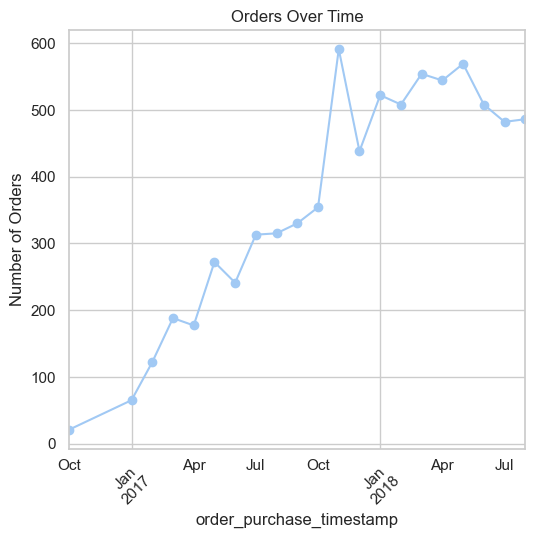

In [414]:
# Create figure with multiple subplots
fig = plt.figure(figsize=(20, 25))

# 1. Orders over time
plt.subplot(4, 3, 1)
monthly_orders = master_df.groupby([master_df['order_purchase_timestamp'].dt.to_period('M')])['order_id'].nunique()
monthly_orders.plot(kind='line', marker='o')
plt.title('Orders Over Time')
plt.xticks(rotation=45)
plt.ylabel('Number of Orders')

The graph

Text(0, 0.5, 'Revenue (R$)')

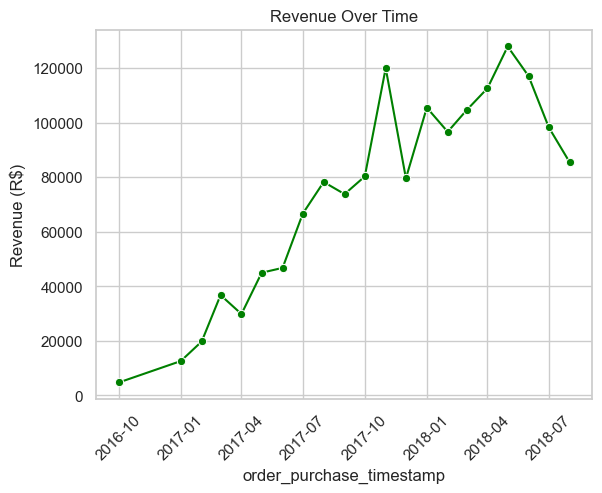

In [415]:
# Step 1: Aggregate revenue by month
monthly_revenue = master_df.groupby(master_df['order_purchase_timestamp'].dt.to_period('M'))['payment_value'].sum().reset_index()
monthly_revenue['order_purchase_timestamp'] = monthly_revenue['order_purchase_timestamp'].dt.to_timestamp()

# Step 2: Plot using Seaborn

sns.lineplot(data=monthly_revenue, x='order_purchase_timestamp', y='payment_value', marker='o', color='green')
plt.title('Revenue Over Time')
plt.xticks(rotation=45)
plt.ylabel('Revenue (R$)')

In [416]:
# Prepare the data
top_categories = master_df['product_category_name_english'].value_counts().head(10)
top_categories = top_categories.sort_values(ascending=True)  # Sort for horizontal bar chart

# Create the bar chart
fig = px.bar(
    top_categories,
    x=top_categories.values,
    y=top_categories.index,
    orientation='h',
    labels={'x': 'Number of Orders', 'y': 'Product Category'},
    title='Top 10 Product Categories'
)

# Show the figure
fig.show()

---

### RFM Analysis and Segmentation

In [417]:
print("\nPerforming RFM Analysis...")

# Calculate RFM quintiles
customer_metrics['R_score'] = pd.qcut(customer_metrics['recency'], 5, labels=[5,4,3,2,1])
customer_metrics['F_score'] = pd.qcut(customer_metrics['frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
customer_metrics['M_score'] = pd.qcut(customer_metrics['monetary'], 5, labels=[1,2,3,4,5])

# Combine RFM scores
customer_metrics['RFM_Score'] = (customer_metrics['R_score'].astype(str) +
                                customer_metrics['F_score'].astype(str) +
                                customer_metrics['M_score'].astype(str))

# Define customer segments
def segment_customers(row):
    if row['RFM_Score'] in ['555', '554', '544', '545', '454', '455', '445']:
        return 'Champions'
    elif row['RFM_Score'] in ['543', '444', '435', '355', '354', '345', '344', '335']:
        return 'Loyal Customers'
    elif row['RFM_Score'] in ['553', '551', '552', '541', '542', '533', '532', '531', '452', '451']:
        return 'Potential Loyalists'
    elif row['RFM_Score'] in ['512', '511', '422', '421', '412', '411', '311']:
        return 'New Customers'
    elif row['RFM_Score'] in ['155', '154', '144', '214', '215', '115', '114']:
        return 'At Risk'
    elif row['RFM_Score'] in ['331', '321', '231', '241', '251']:
        return 'Need Attention'
    else:
        return 'Others'

customer_metrics['Customer_Segment'] = customer_metrics.apply(segment_customers, axis=1)


Performing RFM Analysis...


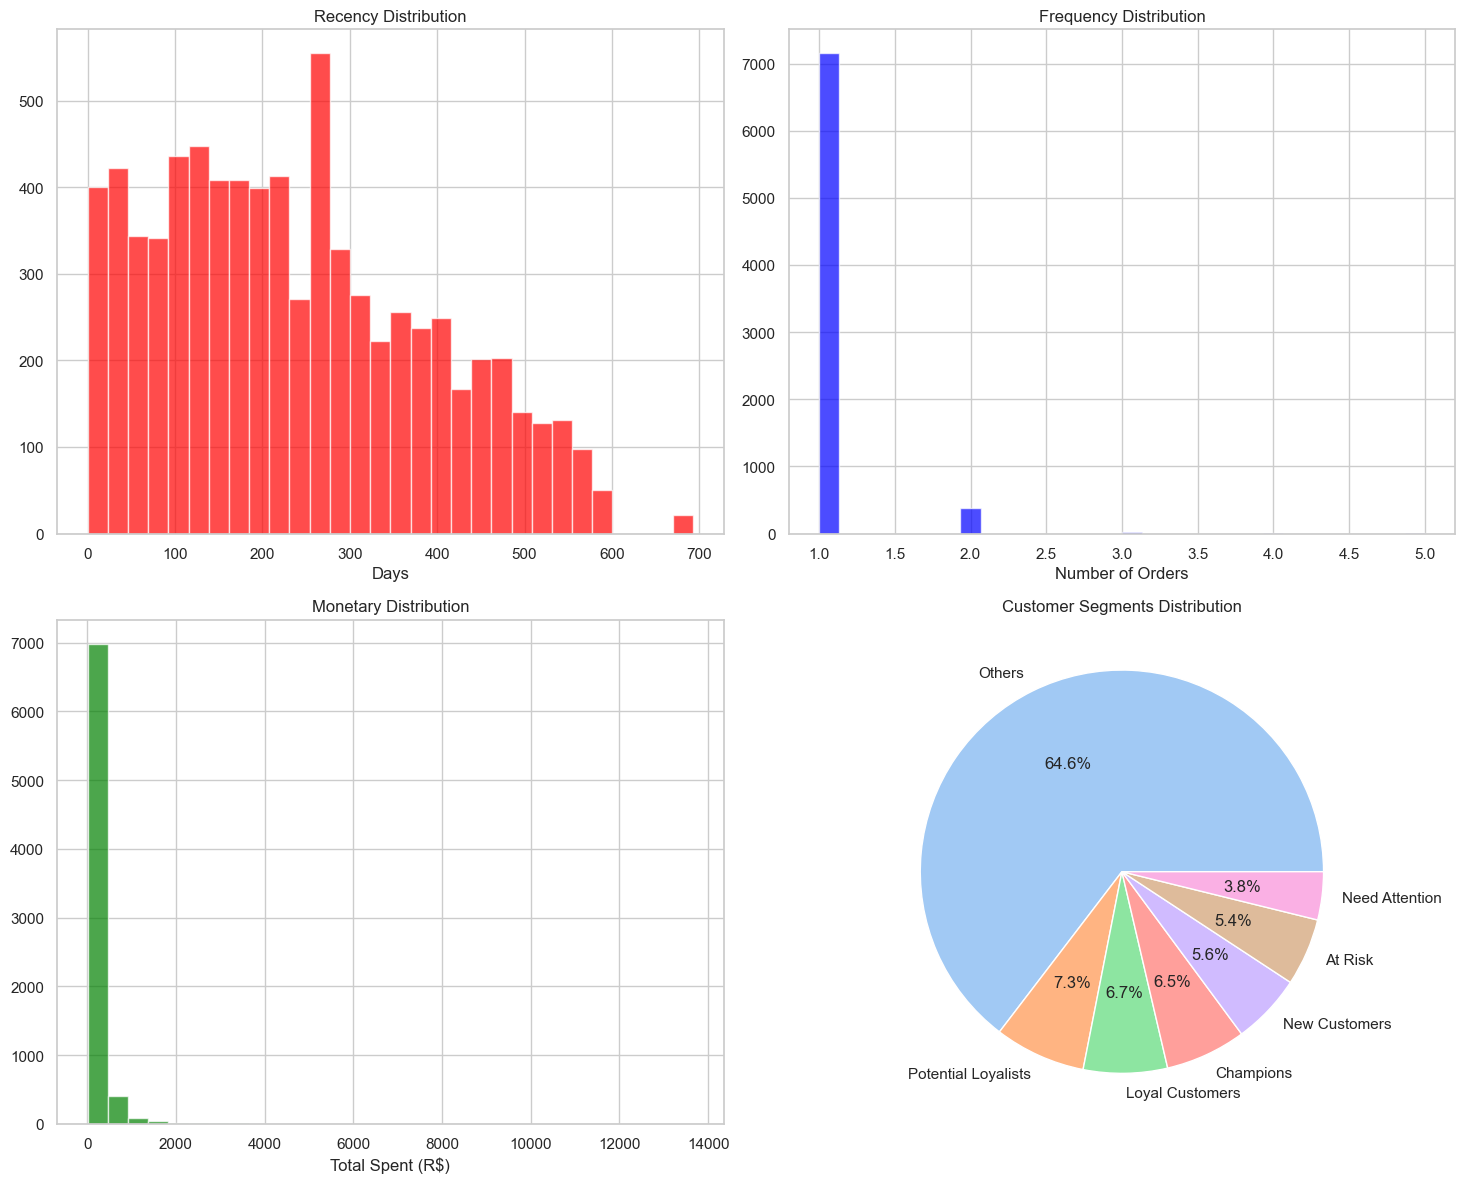

In [418]:
# RFM Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# RFM Score distributions
axes[0,0].hist(customer_metrics['recency'], bins=30, alpha=0.7, color='red')
axes[0,0].set_title('Recency Distribution')
axes[0,0].set_xlabel('Days')

axes[0,1].hist(customer_metrics['frequency'], bins=30, alpha=0.7, color='blue')
axes[0,1].set_title('Frequency Distribution')
axes[0,1].set_xlabel('Number of Orders')

axes[1,0].hist(customer_metrics['monetary'], bins=30, alpha=0.7, color='green')
axes[1,0].set_title('Monetary Distribution')
axes[1,0].set_xlabel('Total Spent (R$)')

# Customer segments
segment_counts = customer_metrics['Customer_Segment'].value_counts()
axes[1,1].pie(segment_counts.values, labels=segment_counts.index, autopct='%1.1f%%')
axes[1,1].set_title('Customer Segments Distribution')

plt.tight_layout()
plt.show()

In [419]:
# RFM Summary Statistics
print("\nRFM Analysis Summary:")
print(customer_metrics[['recency', 'frequency', 'monetary']].describe())
print("\nCustomer Segments:")
print(customer_metrics['Customer_Segment'].value_counts())


RFM Analysis Summary:
           recency    frequency      monetary
count  7559.000000  7559.000000   7559.000000
mean    236.593597     1.058341    204.144327
std     152.256196     0.256504    370.259755
min       0.000000     1.000000      9.590000
25%     113.000000     1.000000     69.120000
50%     218.000000     1.000000    121.930000
75%     345.000000     1.000000    213.495000
max     693.000000     5.000000  13664.080000

Customer Segments:
Customer_Segment
Others                 4884
Potential Loyalists     552
Loyal Customers         509
Champions               489
New Customers           426
At Risk                 408
Need Attention          291
Name: count, dtype: int64


In [420]:
customer_metrics.head()

,customer_unique_id,order_purchase_timestamp_count,order_purchase_timestamp_max,payment_value_sum,payment_value_mean,delivery_days_mean,price_sum,price_mean,recency,frequency,monetary,R_score,F_score,M_score,RFM_Score,Customer_Segment
0,0004bd2a26a76fe21f786e4fbd80607f,1,2018-04-05 19:33:16,166.98,166.98,1.0,154.00,154.00,145,1,166.98,4,1,4,414,Others
1,00053a61a98854899e70ed204dd4bafe,2,2018-02-28 11:15:41,838.36,419.18,16.0,382.00,191.00,181,2,838.36,3,5,5,355,Loyal Customers
2,000949456b182f53c18b68d6babc79c1,1,2018-04-23 09:55:46,82.05,82.05,7.0,64.89,64.89,127,1,82.05,4,1,2,412,New Customers
3,001f3c4211216384d5fe59b041ce1461,1,2017-03-19 18:34:36,35.84,35.84,10.0,24.88,24.88,527,1,35.84,1,1,1,111,Others
4,002043098f10ba39a4600b6c52fbfe3c,1,2017-03-26 16:45:59,237.81,237.81,23.0,176.99,176.99,520,1,237.81,1,1,4,114,At Risk


In [421]:
print(customer_metrics.columns)

Index(['customer_unique_id', 'order_purchase_timestamp_count',
       'order_purchase_timestamp_max', 'payment_value_sum',
       'payment_value_mean', 'delivery_days_mean', 'price_sum', 'price_mean',
       'recency', 'frequency', 'monetary', 'R_score', 'F_score', 'M_score',
       'RFM_Score', 'Customer_Segment'],
      dtype='object')


---

### Clustering


Performing Customer Clustering...


/Users/anita/Documents/vscode-projects/capstone-analysis/.venv/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

/Users/anita/Documents/vscode-projects/capstone-analysis/.venv/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

/Users/anita/Documents/vscode-projects/capstone-analysis/.venv/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

/Users/anita/Documents/vscode-projects/capstone-analysis/.venv/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from

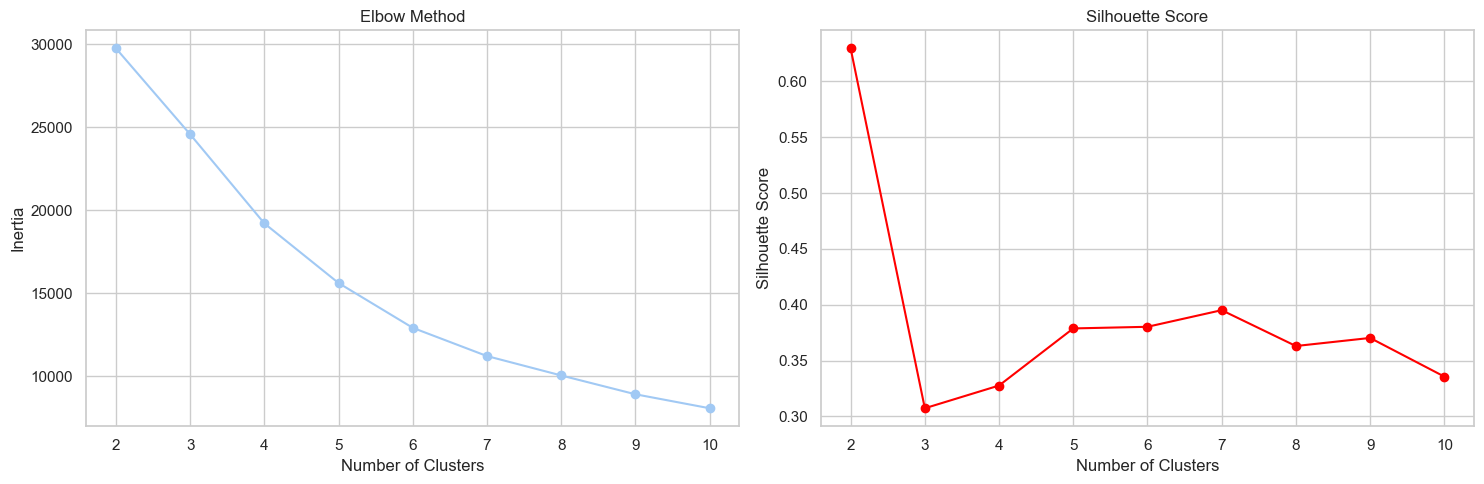

In [422]:
print("\nPerforming Customer Clustering...")

# Prepare data for clustering
clustering_features = ['recency', 'frequency', 'monetary',
                      'payment_value_mean', 'delivery_days_mean',
                      ]

# Clean and prepare clustering data
clustering_data = customer_metrics[clustering_features].fillna(0)

# Standardize features
scaler = StandardScaler()
clustering_scaled = scaler.fit_transform(clustering_data)

# Determine optimal number of clusters using elbow method
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(clustering_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(clustering_scaled, kmeans.labels_))

# Plot elbow curve and silhouette scores
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(K_range, inertias, marker='o')
ax1.set_title('Elbow Method')
ax1.set_xlabel('Number of Clusters')
ax1.set_ylabel('Inertia')

ax2.plot(K_range, silhouette_scores, marker='o', color='red')
ax2.set_title('Silhouette Score')
ax2.set_xlabel('Number of Clusters')
ax2.set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

This perform customer clustering using the K-means algorithm based on RFM (Recency, Frequency, Monetary) metrics and additional features (payment_value_mean, delivery_days_mean).

Both the Elbow Method and Silhouette Score suggest that 4 clusters is likely the optimal number for segmenting the customer data based on the features (recency, frequency, monetary, payment_value_mean, delivery_days_mean).

The elbow at 4 clusters indicates a point of diminishing returns in reducing within-cluster variance, while the peak silhouette score at 4 confirms that the clusters are well-separated and cohesive at this configuration.
This implies that the customer base can be effectively divided into 4 distinct segments, which could represent groups like high-value frequent buyers, recent low-frequency buyers, inactive customers, and a mixed segment, depending on further analysis of the cluster centroids.

In [423]:

# Perform final clustering with optimal number of clusters
optimal_k = 7
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42)
customer_metrics['Cluster'] = kmeans_final.fit_predict(clustering_scaled)

# Analyze clusters
print(f"\nCluster Analysis (K={optimal_k}):")
cluster_summary = customer_metrics.groupby('Cluster')[clustering_features].mean()
print(cluster_summary)

/Users/anita/Documents/vscode-projects/capstone-analysis/.venv/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning




Cluster Analysis (K=7):
            recency  frequency      monetary  payment_value_mean  \
Cluster                                                            
0        227.985154   1.000000    155.029215          155.029215   
1        222.603774   1.622642   2999.865283         2013.263019   
2        116.345844   1.000000    133.146017          133.146017   
3        234.303109   2.056995    440.294378          214.354974   
4        391.448422   1.000000    135.552252          135.552252   
5        222.505650   1.000000    770.893616          770.893616   
6        333.000000   1.000000  13664.080000        13664.080000   

         delivery_days_mean  
Cluster                      
0                 28.486744  
1                 12.606981  
2                  8.183933  
3                 11.097591  
4                 10.103541  
5                 12.757062  
6                 18.000000  


* Cluster Assignment: Each customer in the customer_metrics DataFrame is assigned to one of 7 clusters based on their standardized values of recency, frequency, monetary value, average payment value, and average delivery days. This segmentation groups customers with similar behaviors.
* Cluster Characteristics: The cluster_summary output provides a profile of each cluster by showing the average values of the selected features. For example:
 * A cluster with low recency (recent purchases), high frequency (frequent purchases), and high monetary (high spend) might represent "Champions" or loyal high-value customers.
 * A cluster with high recency (older purchases), low frequency, and low monetary might indicate "At Risk" or inactive customers.
 * The inclusion of payment_value_mean and delivery_days_mean adds insights into payment preferences and delivery experiences, potentially identifying clusters with specific transactional or logistical behaviors.

The abobe key highlights identify of distinct customer segments, enabling targeted strategies. 
For instance:
* Clusters with high monetary value can be prioritized for retention campaigns.
* Clusters with long delivery days might need operational improvements.
* Note on Optimal K: The choice of 7 clusters differs from the earlier suggestion of 4 based on the provided elbow and silhouette plots. This could imply a decision to explore more granular segments or a different analysis justifying 7 clusters. The effectiveness of this choice should be validated against business goals or additional metrics.


---

### Extra Visualisation

In [424]:
customer_metrics.head(10)

,customer_unique_id,order_purchase_timestamp_count,order_purchase_timestamp_max,payment_value_sum,payment_value_mean,delivery_days_mean,price_sum,price_mean,recency,frequency,monetary,R_score,F_score,M_score,RFM_Score,Customer_Segment,Cluster
0,0004bd2a26a76fe21f786e4fbd80607f,1,2018-04-05 19:33:16,166.98,166.98,1.0,154.00,154.00,145,1,166.98,4,1,4,414,Others,2
1,00053a61a98854899e70ed204dd4bafe,2,2018-02-28 11:15:41,838.36,419.18,16.0,382.00,191.00,181,2,838.36,3,5,5,355,Loyal Customers,3
2,000949456b182f53c18b68d6babc79c1,1,2018-04-23 09:55:46,82.05,82.05,7.0,64.89,64.89,127,1,82.05,4,1,2,412,New Customers,2
3,001f3c4211216384d5fe59b041ce1461,1,2017-03-19 18:34:36,35.84,35.84,10.0,24.88,24.88,527,1,35.84,1,1,1,111,Others,4
4,002043098f10ba39a4600b6c52fbfe3c,1,2017-03-26 16:45:59,237.81,237.81,23.0,176.99,176.99,520,1,237.81,1,1,4,114,At Risk,4
5,0027324a96d26a2bc7d69262f83c8403,1,2018-03-25 11:51:37,46.78,46.78,3.0,37.90,37.90,156,1,46.78,4,1,1,411,New Customers,2
6,00293787e2aec37a9c253b63fdfe2049,2,2017-10-27 14:25:35,515.74,257.87,12.0,237.80,118.90,305,2,515.74,2,5,5,255,Others,3
7,002ae492472e45ad6ebeb7a625409392,1,2017-10-08 23:56:02,218.66,218.66,11.0,44.99,44.99,324,1,218.66,2,1,4,214,At Risk,4
8,002bdeb33da5b1b3ce8b9c822f749c82,1,2017-12-05 19:04:42,38.09,38.09,8.0,23.99,23.99,266,1,38.09,3,1,1,311,New Customers,4
9,003162bf0351f47a1a247992b8b9b42d,1,2018-07-14 15:45:27,536.60,536.60,9.0,514.90,514.90,45,1,536.60,5,1,5,515,Others,5


In [425]:
master_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,payment_sequential,payment_type,payment_installments,payment_value,seller_zip_code_prefix,seller_city,seller_state,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state,order_year,order_month,order_dayofweek,order_hour,delivery_days,product_volume,price_per_gram
0,cac247cece621e1bc64748d44331d22d,a39a11e156aa248ef573dbb7c65580d2,delivered,2016-10-05 12:34:04,2016-10-06 15:49:11,2016-10-30 15:24:49,2016-11-04 14:31:26,2016-12-07,1979dc402581a74e2bd0c0853951311d,52091,Recife,PE,1,eba7488e1c67729f045ab43fac426f2e,620c87c171fb2a6dd6e8bb4dec959fc6,2016-10-21 16:23:22,249.90,23.87,perfumaria,43.0,259.0,1.0,610.0,22.0,14.0,16.0,perfumery,1.0,credit_card,10.0,273.77,25645,Petropolis,RJ,52091.0,-8.004623,-34.934960,Recife,PE,2016,10,2,12,30,4928.0,0.409002
1,a9fc3ae13c740ad46532fd50b61c69d5,04a043776b45158df5f274435321c199,delivered,2016-10-04 22:43:33,2016-10-06 15:44:56,2016-10-10 15:44:57,2016-10-13 15:44:57,2016-11-28,7e6f4c38a581cced287444d779368aed,35770,Caetanopolis,MG,1,bd701724b9bc9f955e22db8ec65b5097,bac44fa8e13424950488659b5f765c41,2016-10-10 15:44:57,19.90,14.52,moveis_decoracao,62.0,445.0,2.0,300.0,21.0,12.0,12.0,furniture_decor,1.0,credit_card,3.0,34.42,4534,Sao Paulo,SP,35770.0,-19.303656,-44.409527,Caetanópolis,MG,2016,10,1,22,8,3024.0,0.066113
2,4fb7f38042d214ada4d81cc23d228cc8,92da31c4d9d81552801e3c1a6194b796,delivered,2016-10-10 00:01:50,2016-10-11 10:44:13,2016-10-14 18:00:00,2016-11-16 17:17:53,2016-12-14,b74deaa44a000da4ce9bf2913cb8e232,58305,Bayeux,PB,1,dd6a505f83dd3c6326aa9856519e0978,fa40cc5b934574b62717c68f3d678b6d,2016-10-15 10:44:13,49.90,24.84,brinquedos,43.0,623.0,5.0,200.0,16.0,7.0,11.0,toys,1.0,boleto,1.0,74.74,2310,Sao Paulo,SP,58305.0,-7.128322,-34.913191,Bayeux,PB,2016,10,0,0,37,1232.0,0.248259
3,14b01335f19b97fce1437168032ae388,10d74e1a3adaeada0d8da4a2b2891cc3,delivered,2016-10-05 19:09:33,2016-10-06 15:59:18,2016-10-15 12:26:22,2016-10-18 20:37:33,2016-11-29,abcee124c52c041bafc381cbc0036d24,13081,Campinas,SP,1,ad5396bf96af6ede77130e54ad266c61,184a67a8f9f63234d3a92340bbdb727f,2016-10-10 15:59:20,22.37,39.93,moveis_decoracao,39.0,252.0,1.0,900.0,16.0,34.0,34.0,furniture_decor,1.0,credit_card,3.0,162.39,89220,Joinville,SC,13081.0,-22.857408,-47.067493,Campinas,SP,2016,10,2,19,13,18496.0,0.024828
4,3b2ca3293a7ce539ea2379d704fa37ce,06a70917afd2dcd59396e1eac836c646,delivered,2016-10-05 12:44:09,2016-10-06 15:47:17,2016-11-17 11:54:02,2016-11-17 19:53:49,2016-11-25,451c36d15ca9729da50f130f5c0f1c59,31870,Belo Horizonte,MG,1,33e0cfd1cd80a0491da068d7a7f93ff8,dd2bdf855a9172734fbc3744021ae9b9,2016-10-10 15:47:18,169.90,14.97,cama_mesa_banho,44.0,501.0,1.0,2400.0,30.0,30.0,30.0,bed_bath_table,1.0,credit_card,5.0,184.87,31255,Belo Horizonte,MG,31870.0,-19.843643,-43.904064,Belo Horizonte,MG,2016,10,2,12,43,27000.0,0.070762


In [426]:
customer_metrics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7559 entries, 0 to 7558
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   customer_unique_id              7559 non-null   object        
 1   order_purchase_timestamp_count  7559 non-null   int64         
 2   order_purchase_timestamp_max    7559 non-null   datetime64[ns]
 3   payment_value_sum               7559 non-null   float64       
 4   payment_value_mean              7559 non-null   float64       
 5   delivery_days_mean              7559 non-null   float64       
 6   price_sum                       7559 non-null   float64       
 7   price_mean                      7559 non-null   float64       
 8   recency                         7559 non-null   int64         
 9   frequency                       7559 non-null   int64         
 10  monetary                        7559 non-null   float64       
 11  R_sc

/var/folders/hf/46nj1q753jx0d3gy7yg3ns6c0000gn/T/ipykernel_15073/1801875526.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




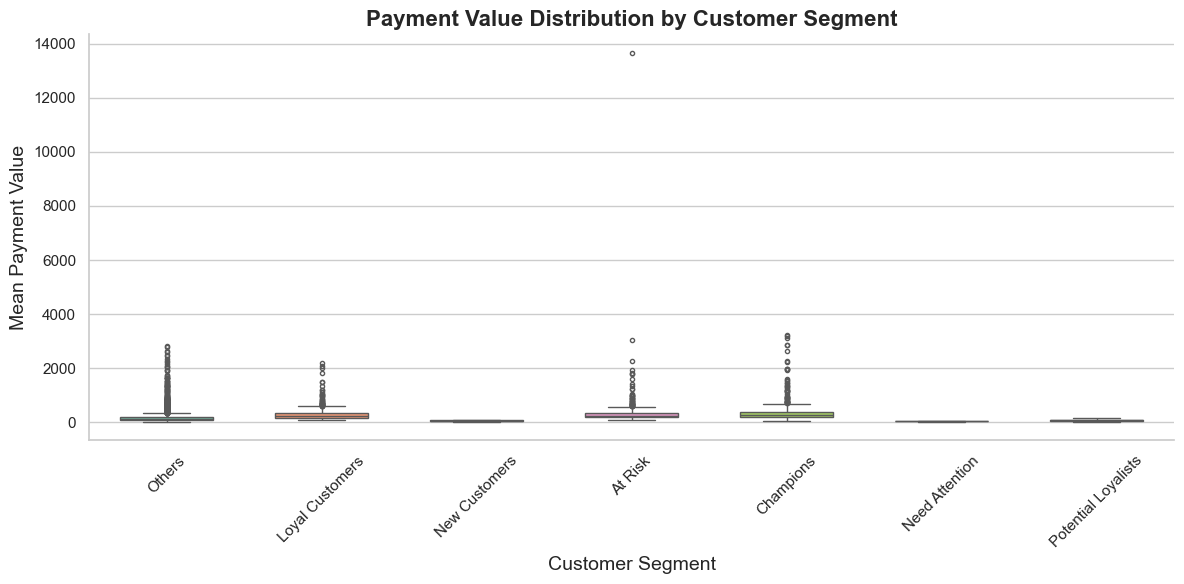

In [427]:
# Set a beautiful theme
sns.set(style="whitegrid", palette="pastel")

# Create the boxplot
plt.figure(figsize=(12, 6))
box = sns.boxplot(
    x='Customer_Segment',
    y='payment_value_mean',
    data=customer_metrics,
    palette='Set2',
    width=0.6,
    fliersize=3
)

# Improve aesthetics
plt.title('Payment Value Distribution by Customer Segment', fontsize=16, fontweight='bold')
plt.xlabel('Customer Segment', fontsize=14)
plt.ylabel('Mean Payment Value', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
sns.despine()

# Show the plot
plt.show()

---

### Save Master Dataset

In [428]:
master_df.to_csv('master_df.csv', index=False)

In [429]:
unique_cities = master_df['geolocation_city'].dropna().unique().tolist()
print(unique_cities)

['Recife', 'Caetanópolis', 'Bayeux', 'Campinas', 'Belo Horizonte', 'Rio De Janeiro', 'Sao Paulo', 'Alem Paraiba', 'Limeira', 'Pocos De Caldas', 'Serra Negra', 'São Paulo', 'Itu', 'Areias', 'Goiânia', 'Sao Roque', 'Navegantes', 'Contagem', 'Camaragibe', 'Nova Iguacu', 'Santa Rita Do Sapucai', 'Sao Sebastiao Do Paraiso', 'Marilia', 'Brasilia', 'Itabaiana', 'Santos', 'Taquaritinga', 'Cianorte', 'Água Boa', 'Manhuacu', 'Parnamirim', 'Rio Claro', 'Uberaba', 'Mogi Mirim', 'Curitiba', 'Vargem Bonita', 'Monte Azul Paulista', 'Xaxim', 'Jatai', 'Coronel Fabriciano', 'Araguaina', 'Sao Jose Dos Campos', 'Sao Lourenco Da Mata', 'Vitória', 'Assis Chateaubriand', 'Porto Velho', 'Sao Carlos', 'Bertioga', 'Londrina', 'Esteio', 'Sao Francisco', 'Floriano', 'Montes Claros', 'Santo André', 'Niterói', 'Sao Paulo Das Missoes', 'Salto Do Lontra', 'Cascavel', 'Califórnia Da Barra', 'Campina Grande', 'Suzano', 'Perdoes', 'Juiz De Fora', 'Campo Bom', 'Canoas', 'Macaparana', 'Rio Do Sul', 'Jundiaí', 'Paracambi',

---

### Hypothesis Testing

Proceed with testing hypothesis 

### Test Hypothesis 1
At Risk and Need Attention segments does not contribute to the revenue after mid-2018.
 

Date range in data: 2016-10-04 14:23:50 to 2018-08-29 08:46:11
Data distribution:
period
Before_Mid_2018    6983
After_Mid_2018     1017
Name: count, dtype: int64
Revenue Analysis for At Risk and Need Attention Segments:
  Customer_Segment           period        sum  count        mean
0          At Risk  Before_Mid_2018  167992.59    478  351.448933
5   Need Attention  Before_Mid_2018   12608.40    292   43.179452

Segment Contribution to Total Revenue:
          Segment           Period    Revenue  Contribution_%
0         At Risk  Before_Mid_2018  167992.59       12.358709
1         At Risk   After_Mid_2018       0.00        0.000000
2  Need Attention  Before_Mid_2018   12608.40        0.927562
3  Need Attention   After_Mid_2018       0.00        0.000000


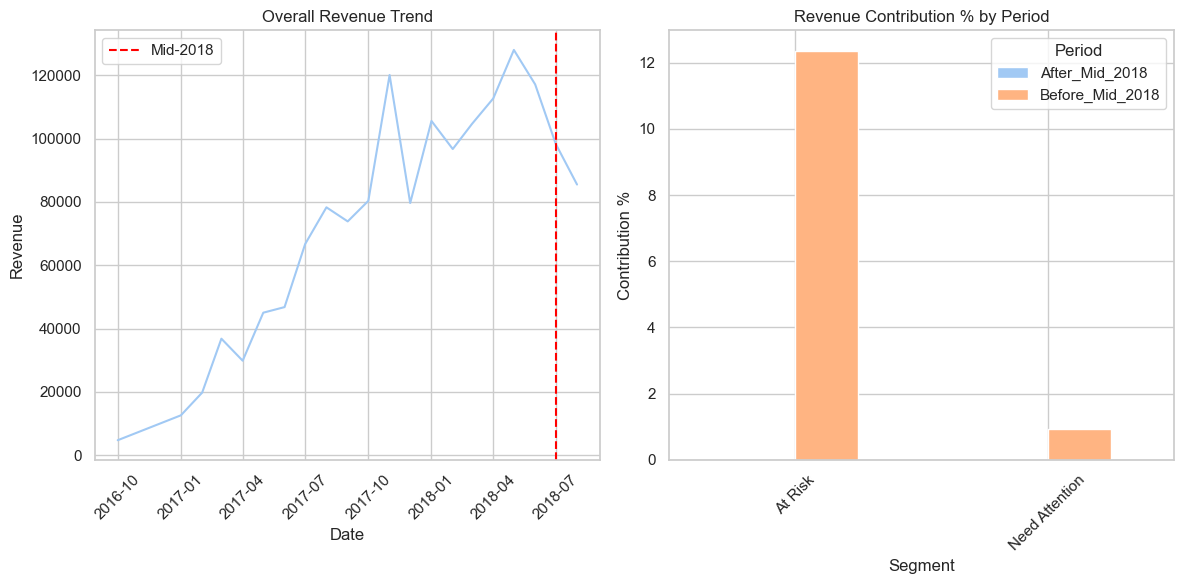


HYPOTHESIS TEST SUMMARY

At Risk Segment:
  Before Mid-2018: 12.36% of total revenue
  After Mid-2018: 0.00% of total revenue
  Change: -12.36 percentage points

Need Attention Segment:
  Before Mid-2018: 0.93% of total revenue
  After Mid-2018: 0.00% of total revenue
  Change: -0.93 percentage points


In [430]:
# Assuming both have 'customer_unique_id' as the key
merged_df = pd.merge(master_df, customer_metrics, on='customer_unique_id', how='inner')

# Step 2: Convert order_purchase_timestamp to datetime if not already done
merged_df['order_purchase_timestamp'] = pd.to_datetime(merged_df['order_purchase_timestamp'])
print(f"Date range in data: {merged_df['order_purchase_timestamp'].min()} to {merged_df['order_purchase_timestamp'].max()}")

# Step 3: Create time periods (before and after mid-2018)
cutoff_date = pd.to_datetime('2018-07-01')  # Mid-2018
merged_df['period'] = merged_df['order_purchase_timestamp'].apply(
    lambda x: 'Before_Mid_2018' if x < cutoff_date else 'After_Mid_2018'
)

print(f"Data distribution:")
print(merged_df['period'].value_counts())

# Step 4: Filter for At Risk and Need Attention segments
at_risk_need_attention = merged_df[
    merged_df['Customer_Segment'].isin(['At Risk', 'Need Attention'])
].copy()

# Step 5: Calculate monthly revenue trends
monthly_revenue = merged_df.groupby([
    merged_df['order_purchase_timestamp'].dt.to_period('M'),
    'Customer_Segment'
])['payment_value'].sum().reset_index()

monthly_revenue['order_purchase_timestamp'] = monthly_revenue['order_purchase_timestamp'].astype(str)

# Step 6: Overall revenue trend analysis
overall_monthly = merged_df.groupby(
    merged_df['order_purchase_timestamp'].dt.to_period('M')
)['payment_value'].sum().reset_index()

# Plot overall revenue trend
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
overall_monthly['order_purchase_timestamp'] = pd.to_datetime(overall_monthly['order_purchase_timestamp'].astype(str))
plt.plot(overall_monthly['order_purchase_timestamp'], overall_monthly['payment_value'])
plt.axvline(x=pd.to_datetime(cutoff_date), color='red', linestyle='--', label='Mid-2018')
plt.title('Overall Revenue Trend')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.legend()

# Step 7: Analyze segment contribution before and after mid-2018
segment_period_revenue = merged_df.groupby(['Customer_Segment', 'period'])['payment_value'].agg(['sum', 'count', 'mean']).reset_index()

# Focus on At Risk and Need Attention
target_segments = segment_period_revenue[
    segment_period_revenue['Customer_Segment'].isin(['At Risk', 'Need Attention'])
]

print("Revenue Analysis for At Risk and Need Attention Segments:")
print("=" * 60)
print(target_segments)

# Step 8: Calculate percentage contribution to total revenue
total_revenue_by_period = merged_df.groupby('period')['payment_value'].sum()

segment_contribution = []
for segment in ['At Risk', 'Need Attention']:
    for period in ['Before_Mid_2018', 'After_Mid_2018']:
        segment_revenue = merged_df[
            (merged_df['Customer_Segment'] == segment) &
            (merged_df['period'] == period)
        ]['payment_value'].sum()

        total_revenue = total_revenue_by_period[period]
        contribution_pct = (segment_revenue / total_revenue) * 100

        segment_contribution.append({
            'Segment': segment,
            'Period': period,
            'Revenue': segment_revenue,
            'Contribution_%': contribution_pct
        })

contribution_df = pd.DataFrame(segment_contribution)
print("\nSegment Contribution to Total Revenue:")
print("=" * 40)
print(contribution_df)

# Step 9: Visualize the findings
plt.subplot(1, 2, 2)
pivot_contribution = contribution_df.pivot(index='Segment', columns='Period', values='Contribution_%')
pivot_contribution.plot(kind='bar', ax=plt.gca())
plt.title('Revenue Contribution % by Period')
plt.ylabel('Contribution %')
plt.xticks(rotation=45)
plt.legend(title='Period')

plt.tight_layout()
plt.show()

# Step 10: Statistical significance test
from scipy.stats import ttest_ind

# Compare revenue per customer for these segments before vs after
at_risk_before = merged_df[
    (merged_df['Customer_Segment'] == 'At Risk') &
    (merged_df['period'] == 'Before_Mid_2018')
]['payment_value']

at_risk_after = merged_df[
    (merged_df['Customer_Segment'] == 'At Risk') &
    (merged_df['period'] == 'After_Mid_2018')
]['payment_value']

need_attention_before = merged_df[
    (merged_df['Customer_Segment'] == 'Need Attention') &
    (merged_df['period'] == 'Before_Mid_2018')
]['payment_value']

need_attention_after = merged_df[
    (merged_df['Customer_Segment'] == 'Need Attention') &
    (merged_df['period'] == 'After_Mid_2018')
]['payment_value']

# T-tests
if len(at_risk_before) > 0 and len(at_risk_after) > 0:
    t_stat_ar, p_val_ar = ttest_ind(at_risk_before, at_risk_after)
    print(f"\nAt Risk Segment - T-test:")
    print(f"T-statistic: {t_stat_ar:.4f}, P-value: {p_val_ar:.4f}")

if len(need_attention_before) > 0 and len(need_attention_after) > 0:
    t_stat_na, p_val_na = ttest_ind(need_attention_before, need_attention_after)
    print(f"\nNeed Attention Segment - T-test:")
    print(f"T-statistic: {t_stat_na:.4f}, P-value: {p_val_na:.4f}")

# Step 11: Summary insights
print("\n" + "="*50)
print("HYPOTHESIS TEST SUMMARY")
print("="*50)

# Calculate change in contribution
for segment in ['At Risk', 'Need Attention']:
    before_contrib = contribution_df[
        (contribution_df['Segment'] == segment) &
        (contribution_df['Period'] == 'Before_Mid_2018')
    ]['Contribution_%'].iloc[0]

    after_contrib = contribution_df[
        (contribution_df['Segment'] == segment) &
        (contribution_df['Period'] == 'After_Mid_2018')
    ]['Contribution_%'].iloc[0]

    change = after_contrib - before_contrib

    print(f"\n{segment} Segment:")
    print(f"  Before Mid-2018: {before_contrib:.2f}% of total revenue")
    print(f"  After Mid-2018: {after_contrib:.2f}% of total revenue")
    print(f"  Change: {change:+.2f} percentage points")

In [432]:
column_list = merged_df.columns.tolist()
print(column_list)

['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_category_name_english', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value', 'seller_zip_code_prefix', 'seller_city', 'seller_state', 'geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geolocation_state', 'order_year', 'order_month', 'order_dayofweek', 'order_hour', 'delivery_days', 'product_volume', 'price_per_gram', 'order_purchase_timestamp_count', 'order_purchase_times

---

### Test Hypothesis 2
Champions and Loyal Customers show significantly higher purchase frequency and preference for Bed/Bath/Table and Health/Beauty categories compared to other customer segments, indicating these categories drive customer loyalty and repeat purchases.

HYPOTHESIS 2: CATEGORY PREFERENCES OF HIGH-FREQUENCY CUSTOMERS

1. DATA OVERVIEW
Total unique categories: 67
Target categories available: ['bed_bath_table', 'health_beauty']

All available categories:
 1. agro_industry_and_commerce
 2. air_conditioning
 3. art
 4. arts_and_craftmanship
 5. audio
 6. auto
 7. baby
 8. bed_bath_table
 9. books_general_interest
10. books_imported
11. books_technical
12. christmas_supplies
13. cine_photo
14. computers
15. computers_accessories
16. consoles_games
17. construction_tools_construction
18. construction_tools_lights
19. construction_tools_safety
20. cool_stuff
21. costruction_tools_garden
22. costruction_tools_tools
23. diapers_and_hygiene
24. drinks
25. dvds_blu_ray
26. electronics
27. fashio_female_clothing
28. fashion_bags_accessories
29. fashion_male_clothing
30. fashion_shoes
31. fashion_sport
32. fashion_underwear_beach
33. fixed_telephony
34. flowers
35. food
36. food_drink
37. furniture_bedroom
38. furniture_decor
39. furniture_living_ro

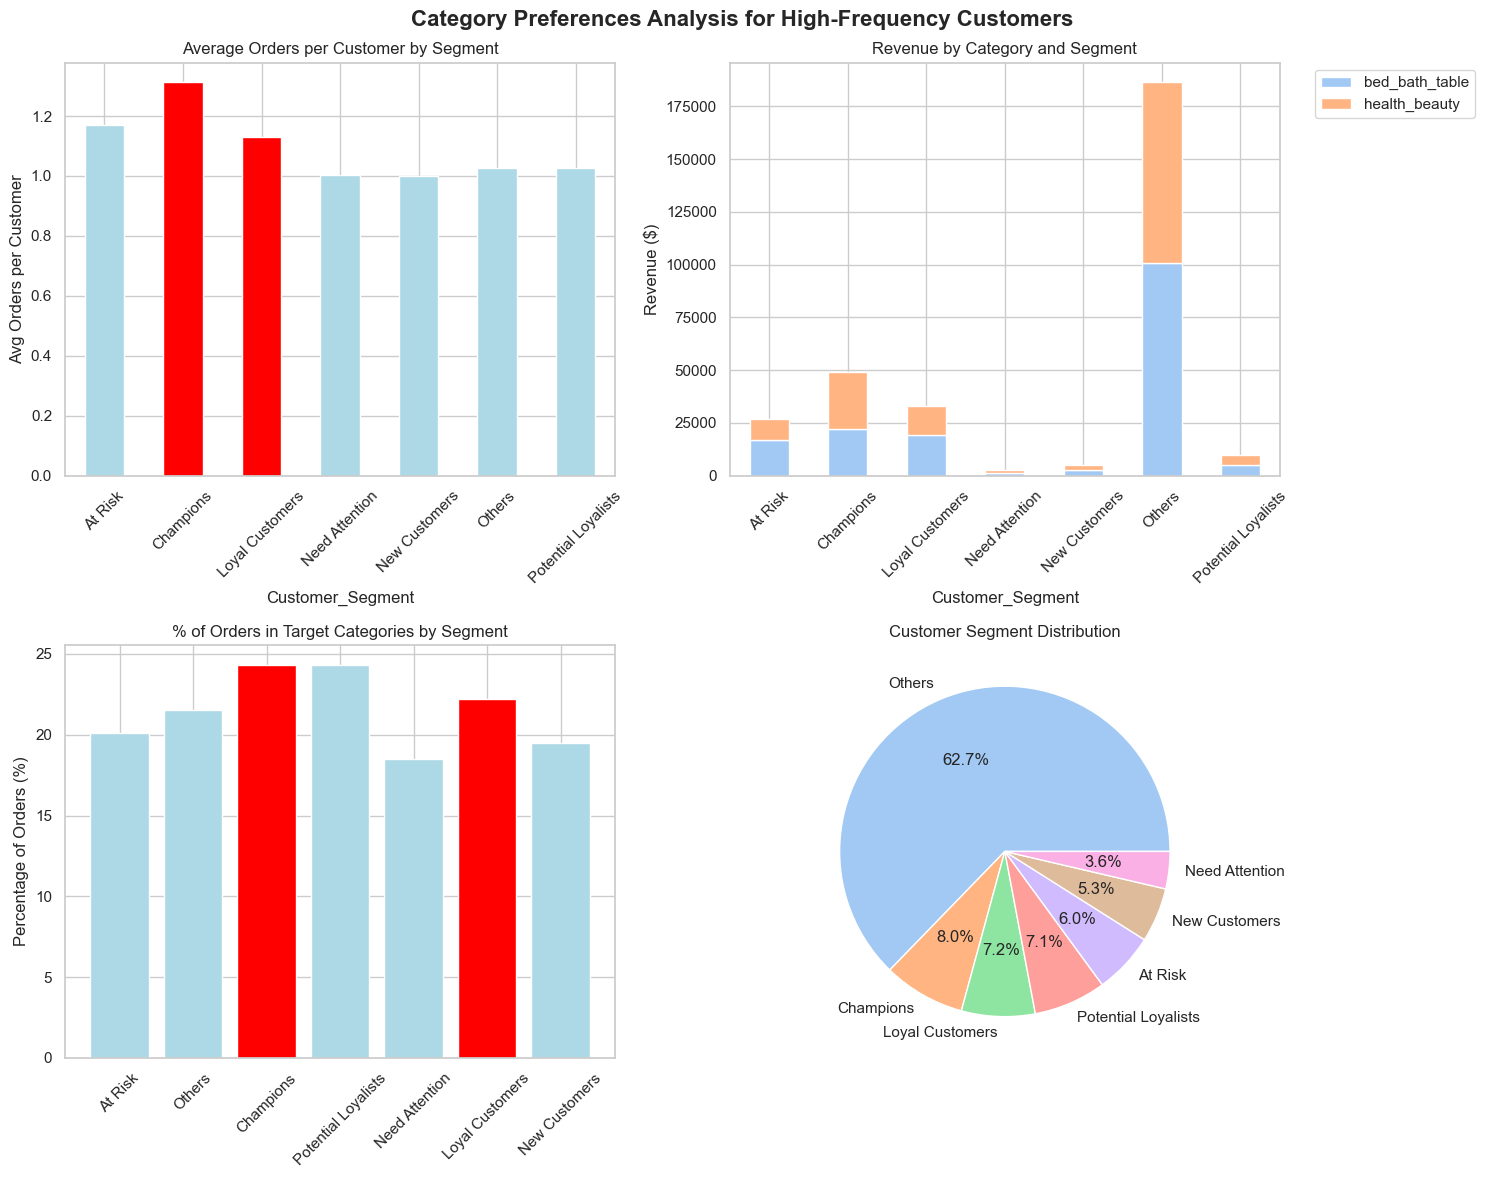


8. HYPOTHESIS TESTING RESULTS

High-Frequency Segments Analysis:
  Segments: ['Champions', 'Loyal Customers']
  Total customers: 998
  Total orders: 1,218
  Avg orders per customer: 1.22

Target Category Performance:
  High-frequency segments in target categories: 23.32% of their orders
  Other segments in target categories: 21.41% of their orders
  Difference: +1.91 percentage points

9. HYPOTHESIS CONCLUSION
✓ HYPOTHESIS SUPPORTED: Statistical significance found (p < 0.05)
✓ High-frequency customers show higher preference for target categories

Key Findings:
  • Champions and Loyal Customers represent 15.2% of all orders
  • They show 23.32% preference for Bed/Bath/Table & Health/Beauty categories
  • This is +1.91 percentage points higher than other segments
  • Statistical significance: Yes (p-value: 0.0000)

ANALYSIS COMPLETE


In [437]:
# Hypothesis 2: Champions and Loyal Customers show significantly higher purchase frequency and preference for Bed/Bath/Table and Health/Beauty categories

print("HYPOTHESIS 2: CATEGORY PREFERENCES OF HIGH-FREQUENCY CUSTOMERS")

# Step 1: Data Preparation and Overview
print("\n1. DATA OVERVIEW")

# Check for the target categories in English names
target_categories = ['bed_bath_table', 'health_beauty']
available_categories = merged_df['product_category_name_english'].unique()
print(f"Total unique categories: {len(available_categories)}")
print(f"Target categories available: {[cat for cat in target_categories if cat in available_categories]}")

# Display all categories to help identify correct names
print("\nAll available categories:")
for i, cat in enumerate(sorted(available_categories)):
    if pd.notna(cat):
        print(f"{i+1:2d}. {cat}")

# Step 2: Define high-frequency customer segments
high_freq_segments = ['Champions', 'Loyal Customers']
other_segments = [seg for seg in merged_df['Customer_Segment'].unique()
                 if seg not in high_freq_segments and pd.notna(seg)]

print(f"\n2. CUSTOMER SEGMENT DISTRIBUTION")
print("-" * 35)
segment_counts = merged_df['Customer_Segment'].value_counts()
print("Customer Segment Distribution:")
for segment, count in segment_counts.items():
    print(f"  {segment}: {count:,} orders")

# Step 3: Quick category verification (streamlined)
print(f"\n3. CATEGORY VERIFICATION")
print("-" * 25)

# Check if exact target categories exist
target_categories_actual = ['bed_bath_table', 'health_beauty']
found_categories = [cat for cat in target_categories_actual if cat in available_categories]

print(f"Target categories found: {found_categories}")
if len(found_categories) != len(target_categories_actual):
    print("⚠️  Some target categories missing. Showing similar categories:")
    for cat in available_categories:
        if pd.notna(cat) and any(term in str(cat).lower() for term in ['bed', 'bath', 'table', 'health', 'beauty']):
            print(f"  - {cat}")

target_categories_actual = found_categories

# Step 4: Calculate purchase frequency by segment and category
print(f"\n4. PURCHASE FREQUENCY ANALYSIS")
print("-" * 35)

# Overall purchase frequency by segment
segment_frequency = merged_df.groupby('Customer_Segment').agg({
    'customer_unique_id': 'nunique',
    'order_id': 'count',
    'payment_value': 'sum'
}).reset_index()

segment_frequency['avg_orders_per_customer'] = segment_frequency['order_id'] / segment_frequency['customer_unique_id']
segment_frequency['avg_revenue_per_customer'] = segment_frequency['payment_value'] / segment_frequency['customer_unique_id']

print("Purchase Frequency by Customer Segment:")
print(segment_frequency.round(2))

# Step 5: Category-specific analysis
if target_categories_actual:
    # Filter data for target categories
    target_category_data = merged_df[
        merged_df['product_category_name_english'].isin(target_categories_actual)
    ].copy()

    print(f"\n5. TARGET CATEGORY PERFORMANCE")
    print("-" * 40)
    print(f"Total orders in target categories: {len(target_category_data):,}")

    # Category performance by segment
    category_segment_analysis = target_category_data.groupby(['Customer_Segment', 'product_category_name_english']).agg({
        'order_id': 'count',
        'customer_unique_id': 'nunique',
        'payment_value': 'sum'
    }).reset_index()

    category_segment_analysis['avg_orders_per_customer'] = (
        category_segment_analysis['order_id'] / category_segment_analysis['customer_unique_id']
    )

    print("\nCategory Performance by Customer Segment:")
    print(category_segment_analysis.round(2))

    # Step 6: Statistical Analysis
    print(f"\n6. STATISTICAL TESTS")
    print("-" * 25)


    # Test: Compare high-frequency vs other segments for target categories
    high_freq_target_orders = target_category_data[
        target_category_data['Customer_Segment'].isin(high_freq_segments)
    ]['payment_value']

    other_target_orders = target_category_data[
        target_category_data['Customer_Segment'].isin(other_segments)
    ]['payment_value']

    if len(high_freq_target_orders) > 0 and len(other_target_orders) > 0:
        t_stat, t_p_value = ttest_ind(high_freq_target_orders, other_target_orders)
        print(f"\nT-test (High-freq vs Others in target categories):")
        print(f"T-statistic: {t_stat:.4f}")
        print(f"P-value: {t_p_value:.4f}")
        print(f"High-freq mean order value: ${high_freq_target_orders.mean():.2f}")
        print(f"Others mean order value: ${other_target_orders.mean():.2f}")

# Step 7: Visualization
print(f"\n7. CREATING VISUALIZATIONS")
print("-" * 30)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Category Preferences Analysis for High-Frequency Customers', fontsize=16, fontweight='bold')

# Plot 1: Orders per customer by segment
ax1 = axes[0, 0]
segment_freq_plot = segment_frequency.set_index('Customer_Segment')['avg_orders_per_customer']
colors = ['red' if seg in high_freq_segments else 'lightblue' for seg in segment_freq_plot.index]
segment_freq_plot.plot(kind='bar', ax=ax1, color=colors)
ax1.set_title('Average Orders per Customer by Segment')
ax1.set_ylabel('Avg Orders per Customer')
ax1.tick_params(axis='x', rotation=45)

# Plot 2: Revenue contribution by category and segment
if target_categories_actual and len(target_category_data) > 0:
    ax2 = axes[0, 1]
    category_revenue = target_category_data.groupby(['Customer_Segment', 'product_category_name_english'])['payment_value'].sum().unstack(fill_value=0)
    category_revenue.plot(kind='bar', stacked=True, ax=ax2)
    ax2.set_title('Revenue by Category and Segment')
    ax2.set_ylabel('Revenue ($)')
    ax2.tick_params(axis='x', rotation=45)
    ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Plot 3: Category preference percentage
ax3 = axes[1, 0]
if target_categories_actual:
    # Calculate percentage of orders in target categories by segment
    category_pct_data = []
    for segment in merged_df['Customer_Segment'].unique():
        if pd.notna(segment):
            segment_data = merged_df[merged_df['Customer_Segment'] == segment]
            total_orders = len(segment_data)
            target_orders = len(segment_data[segment_data['product_category_name_english'].isin(target_categories_actual)])
            pct = (target_orders / total_orders * 100) if total_orders > 0 else 0
            category_pct_data.append({'Segment': segment, 'Target_Category_Percentage': pct})

    pct_df = pd.DataFrame(category_pct_data)
    colors = ['red' if seg in high_freq_segments else 'lightblue' for seg in pct_df['Segment']]
    ax3.bar(pct_df['Segment'], pct_df['Target_Category_Percentage'], color=colors)
    ax3.set_title('% of Orders in Target Categories by Segment')
    ax3.set_ylabel('Percentage of Orders (%)')
    ax3.tick_params(axis='x', rotation=45)

# Plot 4: Customer distribution
ax4 = axes[1, 1]
segment_counts.plot(kind='pie', ax=ax4, autopct='%1.1f%%')
ax4.set_title('Customer Segment Distribution')
ax4.set_ylabel('')

plt.tight_layout()
plt.show()

# Step 8: Detailed Insights and Hypothesis Conclusion
print(f"\n8. HYPOTHESIS TESTING RESULTS")
print("="*50)

# Calculate key metrics for high-frequency segments
high_freq_data = merged_df[merged_df['Customer_Segment'].isin(high_freq_segments)]
other_data = merged_df[merged_df['Customer_Segment'].isin(other_segments)]

print(f"\nHigh-Frequency Segments Analysis:")
print(f"  Segments: {high_freq_segments}")
print(f"  Total customers: {high_freq_data['customer_unique_id'].nunique():,}")
print(f"  Total orders: {len(high_freq_data):,}")
print(f"  Avg orders per customer: {len(high_freq_data) / high_freq_data['customer_unique_id'].nunique():.2f}")

if target_categories_actual:
    high_freq_target = high_freq_data[high_freq_data['product_category_name_english'].isin(target_categories_actual)]
    other_target = other_data[other_data['product_category_name_english'].isin(target_categories_actual)]

    high_freq_target_pct = len(high_freq_target) / len(high_freq_data) * 100
    other_target_pct = len(other_target) / len(other_data) * 100

    print(f"\nTarget Category Performance:")
    print(f"  High-frequency segments in target categories: {high_freq_target_pct:.2f}% of their orders")
    print(f"  Other segments in target categories: {other_target_pct:.2f}% of their orders")
    print(f"  Difference: {high_freq_target_pct - other_target_pct:+.2f} percentage points")

    # Conclusion
    print(f"\n9. HYPOTHESIS CONCLUSION")
    print("="*30)

    if t_p_value < 0.05:
        print("✓ HYPOTHESIS SUPPORTED: Statistical significance found (p < 0.05)")
    else:
        print("✗ HYPOTHESIS NOT SUPPORTED: No statistical significance found (p ≥ 0.05)")

    if high_freq_target_pct > other_target_pct:
        print("✓ High-frequency customers show higher preference for target categories")
    else:
        print("✗ High-frequency customers do not show higher preference for target categories")

    print(f"\nKey Findings:")
    print(f"  • Champions and Loyal Customers represent {len(high_freq_data)/len(merged_df)*100:.1f}% of all orders")
    print(f"  • They show {high_freq_target_pct:.2f}% preference for Bed/Bath/Table & Health/Beauty categories")
    print(f"  • This is {high_freq_target_pct - other_target_pct:+.2f} percentage points {'higher' if high_freq_target_pct > other_target_pct else 'lower'} than other segments")
    print(f"  • Statistical significance: {'Yes' if t_p_value < 0.05 else 'No'} (p-value: {t_p_value:.4f})")

else:
    print("\n⚠️  WARNING: Target categories not found in dataset.")
    print("Please check the category names and update the analysis accordingly.")

print(f"\n" + "="*70)
print("ANALYSIS COMPLETE")
print("="*70)

---

### Save merged dataset

In [438]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 63 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   order_id                        8000 non-null   object        
 1   customer_id                     8000 non-null   object        
 2   order_status                    8000 non-null   object        
 3   order_purchase_timestamp        8000 non-null   datetime64[ns]
 4   order_approved_at               8000 non-null   datetime64[ns]
 5   order_delivered_carrier_date    8000 non-null   datetime64[ns]
 6   order_delivered_customer_date   8000 non-null   datetime64[ns]
 7   order_estimated_delivery_date   8000 non-null   datetime64[ns]
 8   customer_unique_id              8000 non-null   object        
 9   customer_zip_code_prefix        8000 non-null   int64         
 10  customer_city                   8000 non-null   object        
 11  cust

In [ ]:
#Merged CSV file
merged_df.to_csv('merged_df.csv', index=False)

---